In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [13]:
df = pd.read_csv("Unemployment in India.csv")

df.columns = df.columns.str.strip()

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [14]:
df.shape

(768, 7)

In [15]:
df.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [16]:
df = df.dropna()

In [17]:
region_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values()

region_avg

Region
Meghalaya            4.798889
Odisha               5.657857
Assam                6.428077
Uttarakhand          6.582963
Gujarat              6.663929
Karnataka            6.676071
Sikkim               7.249412
Madhya Pradesh       7.406429
Andhra Pradesh       7.477143
Maharashtra          7.557500
Telangana            7.737857
West Bengal          8.124643
Chhattisgarh         9.240357
Goa                  9.274167
Tamil Nadu           9.284286
Kerala              10.123929
Puducherry          10.215000
Punjab              12.031071
Uttar Pradesh       12.551429
Rajasthan           14.058214
Chandigarh          15.991667
Jammu & Kashmir     16.188571
Delhi               16.495357
Himachal Pradesh    18.540357
Bihar               18.918214
Jharkhand           20.585000
Haryana             26.283214
Tripura             28.350357
Name: Estimated Unemployment Rate (%), dtype: float64

In [18]:
# Remove leading/trailing spaces
df["Date"] = df["Date"].str.strip()

# Now convert to datetime
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")


In [19]:
print(df.columns.tolist())
for col in df.columns:
    print(repr(col))

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']
'Region'
'Date'
'Frequency'
'Estimated Unemployment Rate (%)'
'Estimated Employed'
'Estimated Labour Participation Rate (%)'
'Area'


In [20]:
pre = df[df["Date"] < "2020-03-25"]
post = df[df["Date"] >= "2020-03-25"]

In [21]:
month_avg = df.groupby(df["Date"].dt.month)["Estimated Unemployment Rate (%)"].mean()
month_avg

Date
1      9.950755
2      9.964717
3     10.700577
4     23.641569
5     16.646190
6     10.553462
7      9.033889
8      9.637925
9      9.051731
10     9.900909
11     9.868364
12     9.497358
Name: Estimated Unemployment Rate (%), dtype: float64

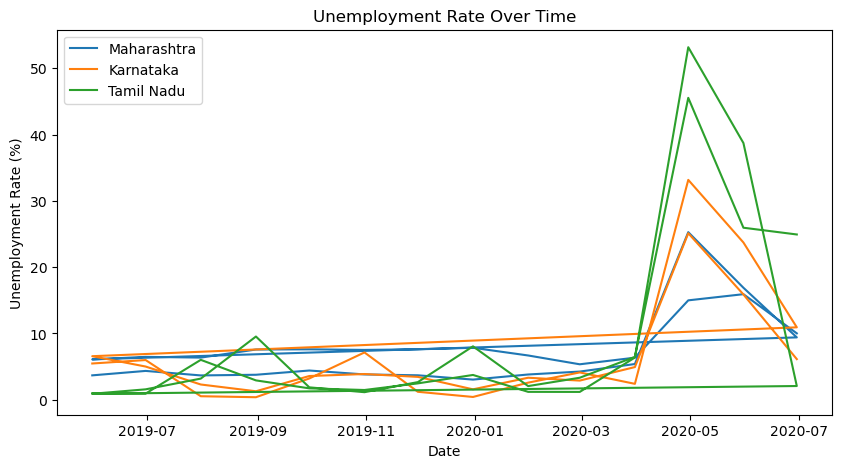

In [22]:
states = ["Maharashtra","Karnataka","Tamil Nadu"]

plt.figure(figsize=(10,5))

for state in states:
    data = df[df["Region"] == state]
    plt.plot(data["Date"], data["Estimated Unemployment Rate (%)"], label=state)

plt.legend()
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.title("Unemployment Rate Over Time")
plt.savefig("rate_over_time.png", dpi=300, bbox_inches="tight")
plt.show()


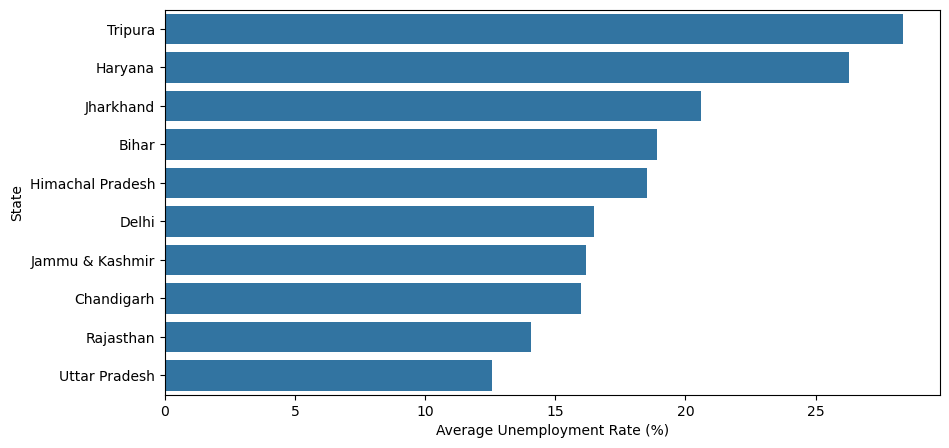

In [23]:
top10 = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top10.values, y=top10.index)
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")
plt.savefig("avg_umemployment.png", dpi=300, bbox_inches="tight")
plt.show()

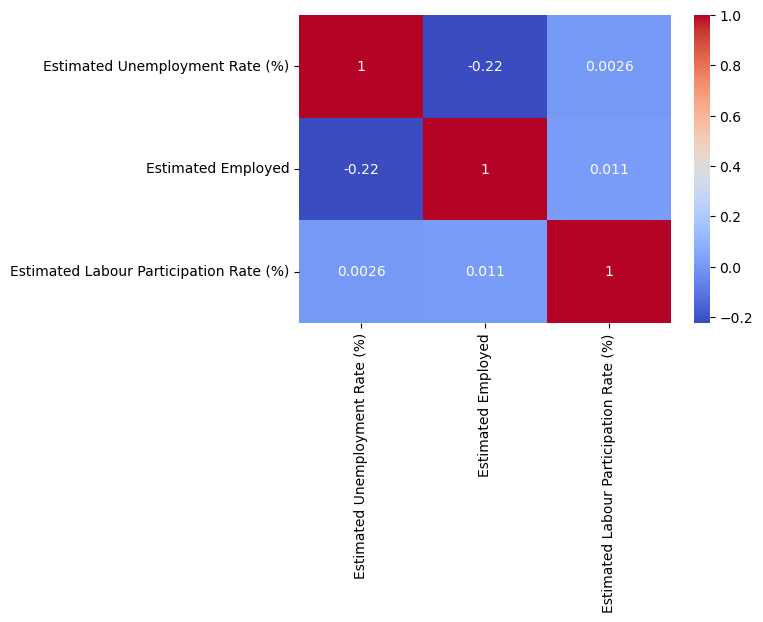

In [24]:
corr = df[[
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.savefig("heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
comparison = pd.DataFrame({
    "Period":["Pre-COVID","Post-COVID"],
    "Average Unemployment Rate":[
        pre["Estimated Unemployment Rate (%)"].mean(),
        post["Estimated Unemployment Rate (%)"].mean()
    ]
})

comparison

,Period,Average Unemployment Rate
0,Pre-COVID,9.509534
1,Post-COVID,17.774363
